In [332]:
import pandas as pd
import numpy as np
import pandasql as ps
from scipy import stats
import matplotlib.pyplot as plt

In [333]:
validator_exits_size_percentage = pd.read_csv('../int/active_exits_size_percentage.csv')
validator_exits_category_percentage = pd.read_csv('../int/active_exits_category_percentage.csv')
validator_exits_pool_percentage = pd.read_csv('../int/active_exits_pool_percentage.csv')
active_validators_size = pd.read_csv('../int/active_validators_size.csv')
active_validators_category = pd.read_csv('../int/active_validators_category.csv')
active_validators_pool = pd.read_csv('../int/active_validators_pool.csv')

In [334]:
deposits_size = pd.read_csv('../int/deposits_size.csv')
deposits_category = pd.read_csv('../int/deposits_category.csv')
staked_pool_size = pd.read_csv('../int/active_validators_size.csv')
staked_category = pd.read_csv('../int/active_validators_category.csv')
deposits_category

,slot,CEX,Liquid Restaking,Liquid Staking,Solo Stakers,Staking Pools,Unidentified,total
0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,300,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,600,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,900,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1200,38368.0,0.0,3456.0,9248.0,1984.0,71872.0,124928.0
...,...,...,...,...,...,...,...,...
29949,8984700,0.0,0.0,0.0,0.0,0.0,0.0,0.0
29950,8985000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
29951,8985300,0.0,0.0,0.0,0.0,0.0,0.0,0.0
29952,8985600,800.0,160.0,94.0,0.0,1824.0,4448.0,7326.0


In [335]:
staked_pool_size_set = staked_pool_size[staked_pool_size['slot'].isin(deposits_size['slot'])]
staked_pool_size_set.reset_index(inplace=True)
staked_pool_size_set = staked_pool_size_set.drop(columns=['index'])

staked_category_set = staked_category[staked_category['slot'].isin(deposits_category['slot'])]
staked_category_set.reset_index(inplace=True)
staked_category_set = staked_category_set.drop(columns=['index'])

deposits_size.set_index('slot', inplace=True)
staked_pool_size_set.set_index('slot', inplace=True)
deposits_percentage_size = deposits_size.divide(staked_pool_size_set, fill_value=0) * 100
deposits_percentage_size.reset_index(inplace=True)

deposits_category.set_index('slot', inplace=True)
staked_category_set.set_index('slot', inplace=True)
deposits_percentage_category = deposits_category.divide(staked_category_set, fill_value=0) * 100
deposits_percentage_category.reset_index(inplace=True)
deposits_percentage_category

,slot,CEX,Liquid Restaking,Liquid Staking,Solo Stakers,Staking Pools,Unidentified,total
0,0,0.000000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000
1,300,0.000000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000
2,600,0.000000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000
3,900,0.000000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000
4,1200,1106.343714,NaN,618.246869,400.519706,318.971061,509.549805,593.115890
...,...,...,...,...,...,...,...,...
29949,8984700,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
29950,8985000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
29951,8985300,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
29952,8985600,0.312612,0.205328,0.028348,0.000000,3.231178,1.688392,0.731024


In [336]:
validator_exits_size_percentage = validator_exits_size_percentage.drop(columns=['Unnamed: 0'])
validator_exits_category_percentage = validator_exits_category_percentage.drop(columns=['Unnamed: 0'])
validator_exits_pool_percentage = validator_exits_pool_percentage.drop(columns=['Unnamed: 0'])
validator_exits_size_percentage = validator_exits_size_percentage[['slot', '1', '2-5', '6-19', '20-99', '100+', 'total']]
validator_exits_size_percentage

,slot,1,2-5,6-19,20-99,100+,total
0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000
1,300.0,0.000000,0.0,0.0,0.0,0.000000,0.000000
2,600.0,0.000000,0.0,0.0,0.0,0.000000,0.000000
3,900.0,0.000000,0.0,0.0,0.0,0.000000,0.000000
4,1200.0,0.000000,0.0,0.0,0.0,0.000000,0.000000
...,...,...,...,...,...,...,...
29949,8984700.0,0.030469,0.0,0.0,0.0,0.009024,0.008583
29950,8985000.0,0.000000,0.0,0.0,0.0,0.001305,0.001198
29951,8985300.0,0.000000,0.0,0.0,0.0,0.000652,0.000599
29952,8985600.0,0.010157,0.0,0.0,0.0,0.000000,0.000100


# RocketPool launch

In [354]:
import pandas as pd
from scipy import stats

# Assuming `validator_exits_size_percentage` DataFrame is already loaded
df = deposits_percentage_size

# Set the event slot (this is an example, you should replace it with the actual event slot if known)
event_slot = 2466000.0  # Replace with the actual event slot

# Define the event window and estimation window
event_window = 50400  # slots
pre_event_window = df[df['slot'] <= event_slot]
post_event_window = df[df['slot'] > event_slot]

# Filter the slots for the event window
pre_event_df = pre_event_window[(pre_event_window['slot'] > event_slot - event_window) & (pre_event_window['slot'] <= event_slot)]
post_event_df = post_event_window[(post_event_window['slot'] <= event_slot + event_window) & (post_event_window['slot'] > event_slot)]

# Drop NaN values in the pre-event and post-event dataframes
pre_event_df = pre_event_df.dropna()
post_event_df = post_event_df.dropna()

# Columns to analyze
columns = ['1', '2-5', '6-19', '20-99', '100+']

# Function to calculate statistics and perform t-tests
def calculate_statistics(pre_event_df, post_event_df, columns):
    results = []

    # Calculate and append the 'total' row
    pre_event_total_mean = pre_event_df['total'].mean()
    pre_event_total_std = pre_event_df['total'].std()
    post_event_total_mean = post_event_df['total'].mean()
    post_event_total_std = post_event_df['total'].std()
    total_count = pre_event_df['total'].count() + post_event_df['total'].count()

    results.append(['total', pre_event_total_mean, pre_event_total_std, post_event_total_mean, post_event_total_std, 0, 0, total_count])

    for column in columns:
        pre_event_mean = pre_event_df[column].mean()
        pre_event_std = pre_event_df[column].std()
        post_event_mean = post_event_df[column].mean()
        post_event_std = post_event_df[column].std()

        # Calculate the relative change (elasticity)
        pre_event_change = (pre_event_df[column] / pre_event_df['total']).mean()
        post_event_change = (post_event_df[column] / post_event_df['total']).mean()

        # Drop NaN values for the specific column analysis
        pre_event_col = (pre_event_df[column] / pre_event_df['total']).dropna()
        post_event_col = (post_event_df[column] / post_event_df['total']).dropna()

        if len(pre_event_col) > 0 and len(post_event_col) > 0:
            t_stat, p_value = stats.ttest_ind(pre_event_col, post_event_col, equal_var=False)
        else:
            t_stat, p_value = float('nan'), float('nan')

        pre_event_count = pre_event_df[column].count()
        post_event_count = post_event_df[column].count()

        results.append([column, pre_event_mean, pre_event_std, post_event_mean, post_event_std, t_stat, p_value, pre_event_count + post_event_count])
    return results

# Calculate statistics for each column
statistics_size = calculate_statistics(pre_event_df, post_event_df, columns)

# Print the results
print(f"{'Column':<10} {'Pre-event Mean':<15} {'Pre-event Std':<15} {'Post-event Mean':<15} {'Post-event Std':<15} {'T-stat':<10} {'P-value':<10} {'Count (N)':<10}")
for result in statistics_size:
    print(f"{result[0]:<10} {result[1]:<15.4f} {result[2]:<15.4f} {result[3]:<15.4f} {result[4]:<15.4f} {result[5]:<10.4f} {result[6]:<10.4f} {result[7]:<10}")




Column     Pre-event Mean  Pre-event Std   Post-event Mean Post-event Std  T-stat     P-value    Count (N) 
total      0.2548          1.4151          0.1122          0.3670          0.0000     0.0000     336       
1          0.1754          1.0944          0.0984          0.4397          1.3001     0.2055     336       
2-5        0.1333          0.5096          0.1154          0.3958          0.3821     0.7048     336       
6-19       0.9198          9.9784          0.1645          0.8117          0.7658     0.4477     336       
20-99      0.0675          0.5291          0.1162          0.7107          -0.8842    0.3814     336       
100+       0.2481          1.3135          0.1100          0.3970          -0.2811    0.7799     336       


In [355]:
import pandas as pd
from scipy import stats

# Assuming `validator_exits_size_percentage` DataFrame is already loaded
df = deposits_percentage_category

# Set the event slot (this is an example, you should replace it with the actual event slot if known)
event_slot = 2466000.0  # Replace with the actual event slot

# Define the event window and estimation window
event_window = 50400  # slots
pre_event_window = df[df['slot'] <= event_slot]
post_event_window = df[df['slot'] > event_slot]

# Filter the slots for the event window
pre_event_df = pre_event_window[(pre_event_window['slot'] > event_slot - event_window) & (pre_event_window['slot'] <= event_slot)]
post_event_df = post_event_window[(post_event_window['slot'] <= event_slot + event_window) & (post_event_window['slot'] > event_slot)]

# Columns to analyze
columns = df.columns.drop(['slot', 'Unidentified', 'total', 'Liquid Restaking'])

# Function to calculate statistics and perform t-tests
def calculate_statistics(pre_event_df, post_event_df, columns):
    results = []

    # Calculate and append the 'total' row
    pre_event_total_mean = pre_event_df['total'].mean()
    pre_event_total_std = pre_event_df['total'].std()
    post_event_total_mean = post_event_df['total'].mean()
    post_event_total_std = post_event_df['total'].std()
    total_count = pre_event_df['total'].count() + post_event_df['total'].count()

    results.append(['total', pre_event_total_mean, pre_event_total_std, post_event_total_mean, post_event_total_std, 0, 0, total_count])

    for column in columns:
        pre_event_mean = pre_event_df[column].mean()
        pre_event_std = pre_event_df[column].std()
        post_event_mean = post_event_df[column].mean()
        post_event_std = post_event_df[column].std()

        # Calculate the relative change (elasticity)
        pre_event_change = (pre_event_df[column] / pre_event_df['total']).mean()
        post_event_change = (post_event_df[column] / post_event_df['total']).mean()

        # Drop NaN values for the specific column analysis
        pre_event_col = (pre_event_df[column] / pre_event_df['total']).dropna()
        post_event_col = (post_event_df[column] / post_event_df['total']).dropna()

        if len(pre_event_col) > 0 and len(post_event_col) > 0:
            t_stat, p_value = stats.ttest_ind(pre_event_col, post_event_col, equal_var=False)
        else:
            t_stat, p_value = float('nan'), float('nan')

        pre_event_count = pre_event_df[column].count()
        post_event_count = post_event_df[column].count()

        results.append([column, pre_event_mean, pre_event_std, post_event_mean, post_event_std, t_stat, p_value, pre_event_count + post_event_count])
    return results

# Calculate statistics for each column
statistics_cat = calculate_statistics(pre_event_df, post_event_df, columns)

# Print the results
print(f"{'Column':<15} {'Pre-event Mean':<15} {'Pre-event Std':<15} {'Post-event Mean':<15} {'Post-event Std':<15} {'T-stat':<10} {'P-value':<10} {'Count (N)':<10}")
for result in statistics_cat:
    print(f"{result[0]:<15} {result[1]:<15.4f} {result[2]:<15.4f} {result[3]:<15.4f} {result[4]:<15.4f} {result[5]:<10.4f} {result[6]:<10.4f} {result[7]:<10}")




Column          Pre-event Mean  Pre-event Std   Post-event Mean Post-event Std  T-stat     P-value    Count (N) 
total           0.2548          1.4151          0.1122          0.3670          0.0000     0.0000     336       
CEX             0.3195          1.6385          0.1714          0.6762          0.4905     0.6261     336       
Liquid Staking  0.2922          3.7477          0.0287          0.1682          -0.6238    0.5359     336       
Solo Stakers    0.1870          1.5944          0.1386          0.7611          -0.1477    0.8832     336       
Staking Pools   0.0000          0.0000          0.0183          0.2014          -1.3990    0.1746     336       


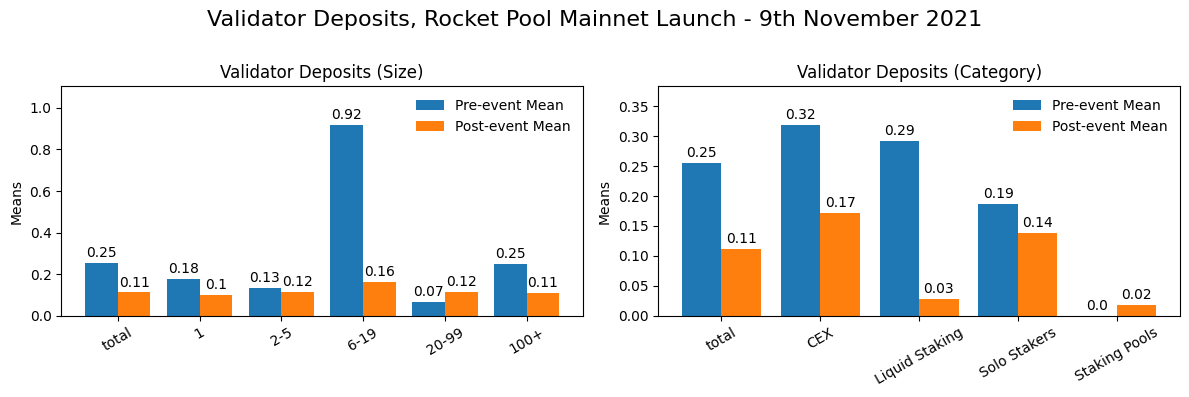

In [356]:
import matplotlib.pyplot as plt

# Extract columns and their respective pre-event and post-event means from the statistics
def extract_means(statistics):
    columns = [result[0] for result in statistics]
    pre_event_means = [result[1] for result in statistics]
    post_event_means = [result[3] for result in statistics]
    return columns, pre_event_means, post_event_means

columns_size, pre_event_means_size, post_event_means_size = extract_means(statistics_size)
columns_cat, pre_event_means_cat, post_event_means_cat = extract_means(statistics_cat)

# Create bar graphs to visualize the pre-event and post-event means
x_size = range(len(columns_size))  # the label locations for size statistics
x_cat = range(len(columns_cat))    # the label locations for category statistics
width = 0.4  # the width of the bars

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))  # Create subplots for side-by-side visualization

# Plot for size statistics
bars1_size = ax1.bar(x_size, pre_event_means_size, width, label='Pre-event Mean')
bars2_size = ax1.bar([i + width for i in x_size], post_event_means_size, width, label='Post-event Mean')

# Calculate y-axis limits
max_height_size = max(pre_event_means_size + post_event_means_size)
ax1.set_ylim(0, max_height_size * 1.2)  # Add 20% to the max height for y-axis limit

ax1.set_ylabel('Means')
ax1.set_title('Validator Deposits (Size)')
ax1.set_xticks([i + width / 2 for i in x_size])
ax1.set_xticklabels(columns_size, rotation=30, ha='center')
ax1.legend(frameon=False)

# Attach a text label above each bar in bars1_size and bars2_size, displaying its height.
for bars in [bars1_size, bars2_size]:
    for bar in bars:
        height = bar.get_height()
        ax1.annotate('{}'.format(round(height, 2)),
                     xy=(bar.get_x() + bar.get_width() / 2, height),
                     xytext=(0, 2),  # Increased vertical offset to avoid overlapping with the box
                     textcoords="offset points",
                     ha='center', va='bottom')

# Plot for category statistics
bars1_cat = ax2.bar(x_cat, pre_event_means_cat, width, label='Pre-event Mean')
bars2_cat = ax2.bar([i + width for i in x_cat], post_event_means_cat, width, label='Post-event Mean')

# Calculate y-axis limits
max_height_cat = max(pre_event_means_cat + post_event_means_cat)
ax2.set_ylim(0, max_height_cat * 1.2)  # Add 20% to the max height for y-axis limit

ax2.set_ylabel('Means')
ax2.set_title('Validator Deposits (Category)')
ax2.set_xticks([i + width / 2 for i in x_cat])
ax2.set_xticklabels(columns_cat, rotation=30, ha='center')
ax2.legend(frameon=False)

# Attach a text label above each bar in bars1_cat and bars2_cat, displaying its height.
for bars in [bars1_cat, bars2_cat]:
    for bar in bars:
        height = bar.get_height()
        ax2.annotate('{}'.format(round(height, 2)),
                     xy=(bar.get_x() + bar.get_width() / 2, height),
                     xytext=(0, 2),  # Increased vertical offset to avoid overlapping with the box
                     textcoords="offset points",
                     ha='center', va='bottom')

# Add a title
fig.suptitle('Validator Deposits, Rocket Pool Mainnet Launch - 9th November 2021', fontsize=16)

fig.tight_layout(rect=[0, 0, 1, 0.97])

plt.show()


# FED Rate Hike

In [357]:
import pandas as pd
from scipy import stats

# Assuming `validator_exits_size_percentage` DataFrame is already loaded
df = deposits_percentage_size

# Set the event slot (this is an example, you should replace it with the actual event slot if known)
event_slot = 4042800  # Replace with the actual event slot

# Define the event window and estimation window
event_window = 50400  # slots
pre_event_window = df[df['slot'] <= event_slot]
post_event_window = df[df['slot'] > event_slot]

# Filter the slots for the event window
pre_event_df = pre_event_window[(pre_event_window['slot'] > event_slot - event_window) & (pre_event_window['slot'] <= event_slot)]
post_event_df = post_event_window[(post_event_window['slot'] <= event_slot + event_window) & (post_event_window['slot'] > event_slot)]

# Drop NaN values in the pre-event and post-event dataframes
pre_event_df = pre_event_df.dropna()
post_event_df = post_event_df.dropna()

# Columns to analyze
columns = ['1', '2-5', '6-19', '20-99', '100+']

# Function to calculate statistics and perform t-tests
def calculate_statistics(pre_event_df, post_event_df, columns):
    results = []

    # Calculate and append the 'total' row
    pre_event_total_mean = pre_event_df['total'].mean()
    pre_event_total_std = pre_event_df['total'].std()
    post_event_total_mean = post_event_df['total'].mean()
    post_event_total_std = post_event_df['total'].std()
    total_count = pre_event_df['total'].count() + post_event_df['total'].count()

    results.append(['total', pre_event_total_mean, pre_event_total_std, post_event_total_mean, post_event_total_std, 0, 0, total_count])

    for column in columns:
        pre_event_mean = pre_event_df[column].mean()
        pre_event_std = pre_event_df[column].std()
        post_event_mean = post_event_df[column].mean()
        post_event_std = post_event_df[column].std()

        # Calculate the relative change (elasticity)
        pre_event_change = (pre_event_df[column] / pre_event_df['total']).mean()
        post_event_change = (post_event_df[column] / post_event_df['total']).mean()

        # Drop NaN values for the specific column analysis
        pre_event_col = (pre_event_df[column] / pre_event_df['total']).dropna()
        post_event_col = (post_event_df[column] / post_event_df['total']).dropna()

        if len(pre_event_col) > 0 and len(post_event_col) > 0:
            t_stat, p_value = stats.ttest_ind(pre_event_col, post_event_col, equal_var=False)
        else:
            t_stat, p_value = float('nan'), float('nan')

        pre_event_count = pre_event_df[column].count()
        post_event_count = post_event_df[column].count()

        results.append([column, pre_event_mean, pre_event_std, post_event_mean, post_event_std, t_stat, p_value, pre_event_count + post_event_count])
    return results

# Calculate statistics for each column
statistics_size = calculate_statistics(pre_event_df, post_event_df, columns)

# Print the results
print(f"{'Column':<10} {'Pre-event Mean':<15} {'Pre-event Std':<15} {'Post-event Mean':<15} {'Post-event Std':<15} {'T-stat':<10} {'P-value':<10} {'Count (N)':<10}")
for result in statistics_size:
    print(f"{result[0]:<10} {result[1]:<15.4f} {result[2]:<15.4f} {result[3]:<15.4f} {result[4]:<15.4f} {result[5]:<10.4f} {result[6]:<10.4f} {result[7]:<10}")




Column     Pre-event Mean  Pre-event Std   Post-event Mean Post-event Std  T-stat     P-value    Count (N) 
total      0.1105          0.5944          0.0903          0.3435          0.0000     0.0000     336       
1          0.0711          0.2864          0.0506          0.2134          -0.7666    0.4485     336       
2-5        0.0791          0.3326          0.1383          0.5297          -1.2337    0.2239     336       
6-19       0.0821          0.4884          0.0688          0.3269          -0.4099    0.6840     336       
20-99      0.1024          0.7906          0.0554          0.2544          0.0592     0.9532     336       
100+       0.1130          0.6515          0.0925          0.3704          0.6592     0.5135     336       


In [358]:
import pandas as pd
from scipy import stats

# Assuming `validator_exits_size_percentage` DataFrame is already loaded
df = deposits_percentage_category

# Set the event slot (this is an example, you should replace it with the actual event slot if known)
event_slot = 4042800  # Replace with the actual event slot

# Define the event window and estimation window
event_window = 50400  # slots
pre_event_window = df[df['slot'] <= event_slot]
post_event_window = df[df['slot'] > event_slot]

# Filter the slots for the event window
pre_event_df = pre_event_window[(pre_event_window['slot'] > event_slot - event_window) & (pre_event_window['slot'] <= event_slot)]
post_event_df = post_event_window[(post_event_window['slot'] <= event_slot + event_window) & (post_event_window['slot'] > event_slot)]

# Columns to analyze
columns = df.columns.drop(['slot', 'Unidentified', 'total', 'Liquid Restaking'])

# Function to calculate statistics and perform t-tests
def calculate_statistics(pre_event_df, post_event_df, columns):
    results = []

    # Calculate and append the 'total' row
    pre_event_total_mean = pre_event_df['total'].mean()
    pre_event_total_std = pre_event_df['total'].std()
    post_event_total_mean = post_event_df['total'].mean()
    post_event_total_std = post_event_df['total'].std()
    total_count = pre_event_df['total'].count() + post_event_df['total'].count()

    results.append(['total', pre_event_total_mean, pre_event_total_std, post_event_total_mean, post_event_total_std, 0, 0, total_count])

    for column in columns:
        pre_event_mean = pre_event_df[column].mean()
        pre_event_std = pre_event_df[column].std()
        post_event_mean = post_event_df[column].mean()
        post_event_std = post_event_df[column].std()

        # Calculate the relative change (elasticity)
        pre_event_change = (pre_event_df[column] / pre_event_df['total']).mean()
        post_event_change = (post_event_df[column] / post_event_df['total']).mean()

        # Drop NaN values for the specific column analysis
        pre_event_col = (pre_event_df[column] / pre_event_df['total']).dropna()
        post_event_col = (post_event_df[column] / post_event_df['total']).dropna()

        if len(pre_event_col) > 0 and len(post_event_col) > 0:
            t_stat, p_value = stats.ttest_ind(pre_event_col, post_event_col, equal_var=False)
        else:
            t_stat, p_value = float('nan'), float('nan')

        pre_event_count = pre_event_df[column].count()
        post_event_count = post_event_df[column].count()

        results.append([column, pre_event_mean, pre_event_std, post_event_mean, post_event_std, t_stat, p_value, pre_event_count + post_event_count])
    return results

# Calculate statistics for each column
statistics_cat = calculate_statistics(pre_event_df, post_event_df, columns)

# Print the results
print(f"{'Column':<15} {'Pre-event Mean':<15} {'Pre-event Std':<15} {'Post-event Mean':<15} {'Post-event Std':<15} {'T-stat':<10} {'P-value':<10} {'Count (N)':<10}")
for result in statistics_cat:
    print(f"{result[0]:<15} {result[1]:<15.4f} {result[2]:<15.4f} {result[3]:<15.4f} {result[4]:<15.4f} {result[5]:<10.4f} {result[6]:<10.4f} {result[7]:<10}")




Column          Pre-event Mean  Pre-event Std   Post-event Mean Post-event Std  T-stat     P-value    Count (N) 
total           0.1105          0.5944          0.0903          0.3435          0.0000     0.0000     336       
CEX             0.2408          1.5392          0.1547          0.7567          0.9807     0.3323     336       
Liquid Staking  0.0193          0.0755          0.0206          0.0864          -0.2313    0.8181     336       
Solo Stakers    0.0962          0.5656          0.4518          3.7664          -0.8700    0.3900     336       
Staking Pools   0.0000          0.0000          0.0000          0.0000          nan        nan        336       


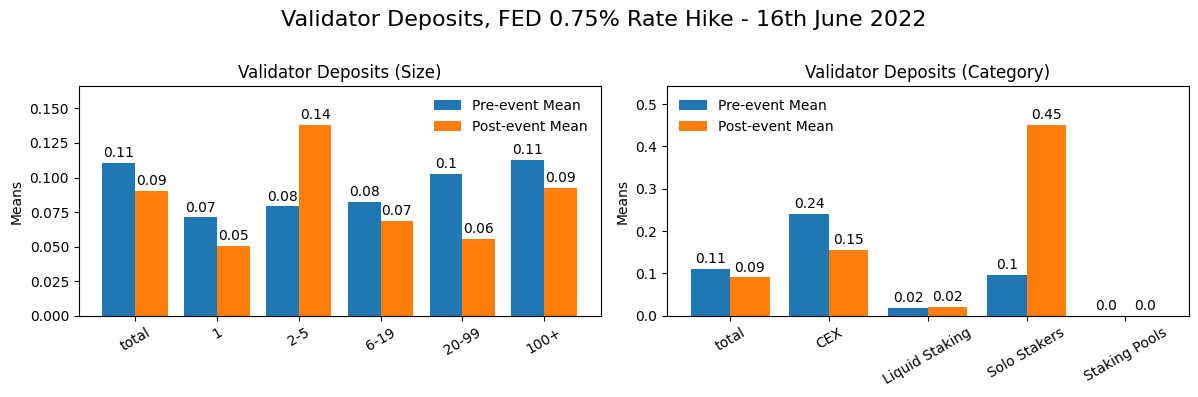

In [359]:
import matplotlib.pyplot as plt

# Extract columns and their respective pre-event and post-event means from the statistics
def extract_means(statistics):
    columns = [result[0] for result in statistics]
    pre_event_means = [result[1] for result in statistics]
    post_event_means = [result[3] for result in statistics]
    return columns, pre_event_means, post_event_means

columns_size, pre_event_means_size, post_event_means_size = extract_means(statistics_size)
columns_cat, pre_event_means_cat, post_event_means_cat = extract_means(statistics_cat)

# Create bar graphs to visualize the pre-event and post-event means
x_size = range(len(columns_size))  # the label locations for size statistics
x_cat = range(len(columns_cat))    # the label locations for category statistics
width = 0.4  # the width of the bars

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))  # Create subplots for side-by-side visualization

# Plot for size statistics
bars1_size = ax1.bar(x_size, pre_event_means_size, width, label='Pre-event Mean')
bars2_size = ax1.bar([i + width for i in x_size], post_event_means_size, width, label='Post-event Mean')

# Calculate y-axis limits
max_height_size = max(pre_event_means_size + post_event_means_size)
ax1.set_ylim(0, max_height_size * 1.2)  # Add 20% to the max height for y-axis limit

ax1.set_ylabel('Means')
ax1.set_title('Validator Deposits (Size)')
ax1.set_xticks([i + width / 2 for i in x_size])
ax1.set_xticklabels(columns_size, rotation=30, ha='center')
ax1.legend(frameon=False)

# Attach a text label above each bar in bars1_size and bars2_size, displaying its height.
for bars in [bars1_size, bars2_size]:
    for bar in bars:
        height = bar.get_height()
        ax1.annotate('{}'.format(round(height, 2)),
                     xy=(bar.get_x() + bar.get_width() / 2, height),
                     xytext=(0, 2),  # Increased vertical offset to avoid overlapping with the box
                     textcoords="offset points",
                     ha='center', va='bottom')

# Plot for category statistics
bars1_cat = ax2.bar(x_cat, pre_event_means_cat, width, label='Pre-event Mean')
bars2_cat = ax2.bar([i + width for i in x_cat], post_event_means_cat, width, label='Post-event Mean')

# Calculate y-axis limits
max_height_cat = max(pre_event_means_cat + post_event_means_cat)
ax2.set_ylim(0, max_height_cat * 1.2)  # Add 20% to the max height for y-axis limit

ax2.set_ylabel('Means')
ax2.set_title('Validator Deposits (Category)')
ax2.set_xticks([i + width / 2 for i in x_cat])
ax2.set_xticklabels(columns_cat, rotation=30, ha='center')
ax2.legend(frameon=False)

# Attach a text label above each bar in bars1_cat and bars2_cat, displaying its height.
for bars in [bars1_cat, bars2_cat]:
    for bar in bars:
        height = bar.get_height()
        ax2.annotate('{}'.format(round(height, 2)),
                     xy=(bar.get_x() + bar.get_width() / 2, height),
                     xytext=(0, 2),  # Increased vertical offset to avoid overlapping with the box
                     textcoords="offset points",
                     ha='center', va='bottom')

# Add a title

fig.suptitle('Validator Deposits, FED 0.75% Rate Hike - 16th June 2022', fontsize=16)

fig.tight_layout(rect=[0, 0, 1, 0.97])

plt.show()


# Ethereum withdrawals

In [343]:
import pandas as pd
from scipy import stats

# Assuming `validator_exits_size_percentage` DataFrame is already loaded
df = deposits_percentage_size

# Set the event slot (this is an example, you should replace it with the actual event slot if known)
event_slot = 6202800  # Replace with the actual event slot

# Define the event window and estimation window
event_window = 50400  # slots
pre_event_window = df[df['slot'] <= event_slot]
post_event_window = df[df['slot'] > event_slot]

# Filter the slots for the event window
pre_event_df = pre_event_window[(pre_event_window['slot'] > event_slot - event_window) & (pre_event_window['slot'] <= event_slot)]
post_event_df = post_event_window[(post_event_window['slot'] <= event_slot + event_window) & (post_event_window['slot'] > event_slot)]

# Drop NaN values in the pre-event and post-event dataframes
pre_event_df = pre_event_df.dropna()
post_event_df = post_event_df.dropna()

# Columns to analyze
columns = ['1', '2-5', '6-19', '20-99', '100+']

# Function to calculate statistics and perform t-tests
def calculate_statistics(pre_event_df, post_event_df, columns):
    results = []

    # Calculate and append the 'total' row
    pre_event_total_mean = pre_event_df['total'].mean()
    pre_event_total_std = pre_event_df['total'].std()
    post_event_total_mean = post_event_df['total'].mean()
    post_event_total_std = post_event_df['total'].std()
    total_count = pre_event_df['total'].count() + post_event_df['total'].count()

    results.append(['total', pre_event_total_mean, pre_event_total_std, post_event_total_mean, post_event_total_std, 0, 0, total_count])

    for column in columns:
        pre_event_mean = pre_event_df[column].mean()
        pre_event_std = pre_event_df[column].std()
        post_event_mean = post_event_df[column].mean()
        post_event_std = post_event_df[column].std()

        # Calculate the relative change (elasticity)
        pre_event_change = (pre_event_df[column] / pre_event_df['total']).mean()
        post_event_change = (post_event_df[column] / post_event_df['total']).mean()

        # Drop NaN values for the specific column analysis
        pre_event_col = (pre_event_df[column] / pre_event_df['total']).dropna()
        post_event_col = (post_event_df[column] / post_event_df['total']).dropna()

        if len(pre_event_col) > 0 and len(post_event_col) > 0:
            t_stat, p_value = stats.ttest_ind(pre_event_col, post_event_col, equal_var=False)
        else:
            t_stat, p_value = float('nan'), float('nan')

        pre_event_count = pre_event_df[column].count()
        post_event_count = post_event_df[column].count()

        results.append([column, pre_event_mean, pre_event_std, post_event_mean, post_event_std, t_stat, p_value, pre_event_count + post_event_count])
    return results

# Calculate statistics for each column
statistics_size = calculate_statistics(pre_event_df, post_event_df, columns)

# Print the results
print(f"{'Column':<10} {'Pre-event Mean':<15} {'Pre-event Std':<15} {'Post-event Mean':<15} {'Post-event Std':<15} {'T-stat':<10} {'P-value':<10} {'Count (N)':<10}")
for result in statistics_size:
    print(f"{result[0]:<10} {result[1]:<15.4f} {result[2]:<15.4f} {result[3]:<15.4f} {result[4]:<15.4f} {result[5]:<10.4f} {result[6]:<10.4f} {result[7]:<10}")




Column     Pre-event Mean  Pre-event Std   Post-event Mean Post-event Std  T-stat     P-value    Count (N) 
total      0.1059          0.2919          0.5290          1.6221          0.0000     0.0000     336       
1          0.1293          1.0617          0.2239          0.6801          1.1875     0.2462     336       
2-5        0.0677          0.2666          0.3332          0.9785          0.0386     0.9695     336       
6-19       0.1177          0.5851          0.5543          1.6367          -0.6749    0.5029     336       
20-99      0.1001          0.4286          0.8990          3.6011          -2.0663    0.0467     336       
100+       0.1062          0.2970          0.5160          1.6456          1.8763     0.0669     336       


In [344]:
import pandas as pd
from scipy import stats

# Assuming `validator_exits_size_percentage` DataFrame is already loaded
df = deposits_percentage_category

# Set the event slot (this is an example, you should replace it with the actual event slot if known)
event_slot = 6202800  # Replace with the actual event slot

# Define the event window and estimation window
event_window = 50400  # slots
pre_event_window = df[df['slot'] <= event_slot]
post_event_window = df[df['slot'] > event_slot]

# Filter the slots for the event window
pre_event_df = pre_event_window[(pre_event_window['slot'] > event_slot - event_window) & (pre_event_window['slot'] <= event_slot)]
post_event_df = post_event_window[(post_event_window['slot'] <= event_slot + event_window) & (post_event_window['slot'] > event_slot)]

# Columns to analyze
columns = df.columns.drop(['slot', 'Unidentified', 'total', 'Liquid Restaking'])

# Function to calculate statistics and perform t-tests
def calculate_statistics(pre_event_df, post_event_df, columns):
    results = []

    # Calculate and append the 'total' row
    pre_event_total_mean = pre_event_df['total'].mean()
    pre_event_total_std = pre_event_df['total'].std()
    post_event_total_mean = post_event_df['total'].mean()
    post_event_total_std = post_event_df['total'].std()
    total_count = pre_event_df['total'].count() + post_event_df['total'].count()

    results.append(['total', pre_event_total_mean, pre_event_total_std, post_event_total_mean, post_event_total_std, 0, 0, total_count])

    for column in columns:
        pre_event_mean = pre_event_df[column].mean()
        pre_event_std = pre_event_df[column].std()
        post_event_mean = post_event_df[column].mean()
        post_event_std = post_event_df[column].std()

        # Calculate the relative change (elasticity)
        pre_event_change = (pre_event_df[column] / pre_event_df['total']).mean()
        post_event_change = (post_event_df[column] / post_event_df['total']).mean()

        # Drop NaN values for the specific column analysis
        pre_event_col = (pre_event_df[column] / pre_event_df['total']).dropna()
        post_event_col = (post_event_df[column] / post_event_df['total']).dropna()

        if len(pre_event_col) > 0 and len(post_event_col) > 0:
            t_stat, p_value = stats.ttest_ind(pre_event_col, post_event_col, equal_var=False)
        else:
            t_stat, p_value = float('nan'), float('nan')

        pre_event_count = pre_event_df[column].count()
        post_event_count = post_event_df[column].count()

        results.append([column, pre_event_mean, pre_event_std, post_event_mean, post_event_std, t_stat, p_value, pre_event_count + post_event_count])
    return results

# Calculate statistics for each column
statistics_cat = calculate_statistics(pre_event_df, post_event_df, columns)

# Print the results
print(f"{'Column':<15} {'Pre-event Mean':<15} {'Pre-event Std':<15} {'Post-event Mean':<15} {'Post-event Std':<15} {'T-stat':<10} {'P-value':<10} {'Count (N)':<10}")
for result in statistics_cat:
    print(f"{result[0]:<15} {result[1]:<15.4f} {result[2]:<15.4f} {result[3]:<15.4f} {result[4]:<15.4f} {result[5]:<10.4f} {result[6]:<10.4f} {result[7]:<10}")




Column          Pre-event Mean  Pre-event Std   Post-event Mean Post-event Std  T-stat     P-value    Count (N) 
total           0.1059          0.2919          0.5290          1.6221          0.0000     0.0000     336       
CEX             0.1445          0.4588          0.3882          1.5009          3.5338     0.0010     336       
Liquid Staking  0.0828          0.2841          0.3110          1.1248          0.1264     0.8999     336       
Solo Stakers    0.0141          0.0761          0.4123          2.0632          -2.4402    0.0210     336       
Staking Pools   0.0706          0.4228          0.2953          0.9209          0.4581     0.6498     336       


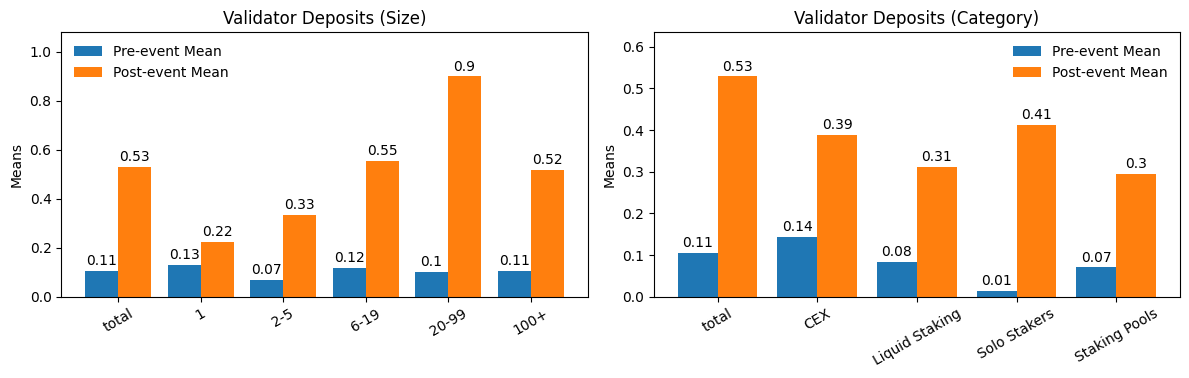

In [345]:
import matplotlib.pyplot as plt

# Extract columns and their respective pre-event and post-event means from the statistics
def extract_means(statistics):
    columns = [result[0] for result in statistics]
    pre_event_means = [result[1] for result in statistics]
    post_event_means = [result[3] for result in statistics]
    return columns, pre_event_means, post_event_means

columns_size, pre_event_means_size, post_event_means_size = extract_means(statistics_size)
columns_cat, pre_event_means_cat, post_event_means_cat = extract_means(statistics_cat)

# Create bar graphs to visualize the pre-event and post-event means
x_size = range(len(columns_size))  # the label locations for size statistics
x_cat = range(len(columns_cat))    # the label locations for category statistics
width = 0.4  # the width of the bars

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))  # Create subplots for side-by-side visualization

# Plot for size statistics
bars1_size = ax1.bar(x_size, pre_event_means_size, width, label='Pre-event Mean')
bars2_size = ax1.bar([i + width for i in x_size], post_event_means_size, width, label='Post-event Mean')

# Calculate y-axis limits
max_height_size = max(pre_event_means_size + post_event_means_size)
ax1.set_ylim(0, max_height_size * 1.2)  # Add 20% to the max height for y-axis limit

ax1.set_ylabel('Means')
ax1.set_title('Validator Deposits (Size)')
ax1.set_xticks([i + width / 2 for i in x_size])
ax1.set_xticklabels(columns_size, rotation=30, ha='center')
ax1.legend(frameon=False)

# Attach a text label above each bar in bars1_size and bars2_size, displaying its height.
for bars in [bars1_size, bars2_size]:
    for bar in bars:
        height = bar.get_height()
        ax1.annotate('{}'.format(round(height, 2)),
                     xy=(bar.get_x() + bar.get_width() / 2, height),
                     xytext=(0, 2),  # Increased vertical offset to avoid overlapping with the box
                     textcoords="offset points",
                     ha='center', va='bottom')

# Plot for category statistics
bars1_cat = ax2.bar(x_cat, pre_event_means_cat, width, label='Pre-event Mean')
bars2_cat = ax2.bar([i + width for i in x_cat], post_event_means_cat, width, label='Post-event Mean')

# Calculate y-axis limits
max_height_cat = max(pre_event_means_cat + post_event_means_cat)
ax2.set_ylim(0, max_height_cat * 1.2)  # Add 20% to the max height for y-axis limit

ax2.set_ylabel('Means')
ax2.set_title('Validator Deposits (Category)')
ax2.set_xticks([i + width / 2 for i in x_cat])
ax2.set_xticklabels(columns_cat, rotation=30, ha='center')
ax2.legend(frameon=False)

# Attach a text label above each bar in bars1_cat and bars2_cat, displaying its height.
for bars in [bars1_cat, bars2_cat]:
    for bar in bars:
        height = bar.get_height()
        ax2.annotate('{}'.format(round(height, 2)),
                     xy=(bar.get_x() + bar.get_width() / 2, height),
                     xytext=(0, 2),  # Increased vertical offset to avoid overlapping with the box
                     textcoords="offset points",
                     ha='center', va='bottom')

# Add a title


fig.tight_layout(rect=[0, 0, 1, 0.97])

plt.show()


# Bitcoin ETF

In [346]:
import pandas as pd
from scipy import stats

# Assuming `validator_exits_size_percentage` DataFrame is already loaded
df = validator_exits_size_percentage

# Set the event slot (this is an example, you should replace it with the actual event slot if known)
event_slot = 8175600.0  # Replace with the actual event slot

# Define the event window and estimation window
event_window = 50400  # slots
pre_event_window = df[df['slot'] <= event_slot]
post_event_window = df[df['slot'] > event_slot]

# Filter the slots for the event window
pre_event_df = pre_event_window[(pre_event_window['slot'] > event_slot - event_window) & (pre_event_window['slot'] <= event_slot)]
post_event_df = post_event_window[(post_event_window['slot'] <= event_slot + event_window) & (post_event_window['slot'] > event_slot)]

# Drop NaN values in the pre-event and post-event dataframes
pre_event_df = pre_event_df.dropna()
post_event_df = post_event_df.dropna()

# Columns to analyze
columns = ['1', '2-5', '6-19', '20-99', '100+']

# Function to calculate statistics and perform t-tests
def calculate_statistics(pre_event_df, post_event_df, columns):
    results = []

    # Calculate and append the 'total' row
    pre_event_total_mean = pre_event_df['total'].mean()
    pre_event_total_std = pre_event_df['total'].std()
    post_event_total_mean = post_event_df['total'].mean()
    post_event_total_std = post_event_df['total'].std()
    total_count = pre_event_df['total'].count() + post_event_df['total'].count()

    results.append(['total', pre_event_total_mean, pre_event_total_std, post_event_total_mean, post_event_total_std, 0, 0, total_count])

    for column in columns:
        pre_event_mean = pre_event_df[column].mean()
        pre_event_std = pre_event_df[column].std()
        post_event_mean = post_event_df[column].mean()
        post_event_std = post_event_df[column].std()

        # Calculate the relative change (elasticity)
        pre_event_change = (pre_event_df[column] / pre_event_df['total']).mean()
        post_event_change = (post_event_df[column] / post_event_df['total']).mean()

        # Drop NaN values for the specific column analysis
        pre_event_col = (pre_event_df[column] / pre_event_df['total']).dropna()
        post_event_col = (post_event_df[column] / post_event_df['total']).dropna()

        if len(pre_event_col) > 0 and len(post_event_col) > 0:
            t_stat, p_value = stats.ttest_ind(pre_event_col, post_event_col, equal_var=False)
        else:
            t_stat, p_value = float('nan'), float('nan')

        pre_event_count = pre_event_df[column].count()
        post_event_count = post_event_df[column].count()

        results.append([column, pre_event_mean, pre_event_std, post_event_mean, post_event_std, t_stat, p_value, pre_event_count + post_event_count])
    return results

# Calculate statistics for each column
statistics_size = calculate_statistics(pre_event_df, post_event_df, columns)

# Print the results
print(f"{'Column':<10} {'Pre-event Mean':<15} {'Pre-event Std':<15} {'Post-event Mean':<15} {'Post-event Std':<15} {'T-stat':<10} {'P-value':<10} {'Count (N)':<10}")
for result in statistics_size:
    print(f"{result[0]:<10} {result[1]:<15.4f} {result[2]:<15.4f} {result[3]:<15.4f} {result[4]:<15.4f} {result[5]:<10.4f} {result[6]:<10.4f} {result[7]:<10}")




Column     Pre-event Mean  Pre-event Std   Post-event Mean Post-event Std  T-stat     P-value    Count (N) 
total      0.0123          0.0037          0.0065          0.0063          0.0000     0.0000     336       
1          0.0019          0.0085          0.0065          0.0143          -4.1082    0.0001     336       
2-5        0.0020          0.0110          0.0077          0.0189          -3.5697    0.0005     336       
6-19       0.0010          0.0053          0.0057          0.0166          -2.9583    0.0035     336       
20-99      0.0022          0.0134          0.0057          0.0225          -2.2007    0.0288     336       
100+       0.0133          0.0042          0.0066          0.0066          6.4862     0.0000     336       


In [347]:
import pandas as pd
from scipy import stats

# Assuming `validator_exits_size_percentage` DataFrame is already loaded
df = validator_exits_category_percentage

# Set the event slot (this is an example, you should replace it with the actual event slot if known)
event_slot = 8175600.0  # Replace with the actual event slot

# Define the event window and estimation window
event_window = 50400  # slots
pre_event_window = df[df['slot'] <= event_slot]
post_event_window = df[df['slot'] > event_slot]

# Filter the slots for the event window
pre_event_df = pre_event_window[(pre_event_window['slot'] > event_slot - event_window) & (pre_event_window['slot'] <= event_slot)]
post_event_df = post_event_window[(post_event_window['slot'] <= event_slot + event_window) & (post_event_window['slot'] > event_slot)]

# Columns to analyze
columns = df.columns.drop(['slot', 'Unidentified', 'total'])

# Function to calculate statistics and perform t-tests
def calculate_statistics(pre_event_df, post_event_df, columns):
    results = []

    # Calculate and append the 'total' row
    pre_event_total_mean = pre_event_df['total'].mean()
    pre_event_total_std = pre_event_df['total'].std()
    post_event_total_mean = post_event_df['total'].mean()
    post_event_total_std = post_event_df['total'].std()
    total_count = pre_event_df['total'].count() + post_event_df['total'].count()

    results.append(['total', pre_event_total_mean, pre_event_total_std, post_event_total_mean, post_event_total_std, 0, 0, total_count])

    for column in columns:
        pre_event_mean = pre_event_df[column].mean()
        pre_event_std = pre_event_df[column].std()
        post_event_mean = post_event_df[column].mean()
        post_event_std = post_event_df[column].std()

        # Calculate the relative change (elasticity)
        pre_event_change = (pre_event_df[column] / pre_event_df['total']).mean()
        post_event_change = (post_event_df[column] / post_event_df['total']).mean()

        # Drop NaN values for the specific column analysis
        pre_event_col = (pre_event_df[column] / pre_event_df['total']).dropna()
        post_event_col = (post_event_df[column] / post_event_df['total']).dropna()

        if len(pre_event_col) > 0 and len(post_event_col) > 0:
            t_stat, p_value = stats.ttest_ind(pre_event_col, post_event_col, equal_var=False)
        else:
            t_stat, p_value = float('nan'), float('nan')

        pre_event_count = pre_event_df[column].count()
        post_event_count = post_event_df[column].count()

        results.append([column, pre_event_mean, pre_event_std, post_event_mean, post_event_std, t_stat, p_value, pre_event_count + post_event_count])
    return results

# Calculate statistics for each column
statistics_cat = calculate_statistics(pre_event_df, post_event_df, columns)

# Print the results
print(f"{'Column':<15} {'Pre-event Mean':<15} {'Pre-event Std':<15} {'Post-event Mean':<15} {'Post-event Std':<15} {'T-stat':<10} {'P-value':<10} {'Count (N)':<10}")
for result in statistics_cat:
    print(f"{result[0]:<15} {result[1]:<15.4f} {result[2]:<15.4f} {result[3]:<15.4f} {result[4]:<15.4f} {result[5]:<10.4f} {result[6]:<10.4f} {result[7]:<10}")




Column          Pre-event Mean  Pre-event Std   Post-event Mean Post-event Std  T-stat     P-value    Count (N) 
total           0.0123          0.0037          0.0065          0.0063          0.0000     0.0000     336       
CEX             0.0012          0.0056          0.0102          0.0158          -9.3502    0.0000     336       
Liquid Restaking 0.0000          0.0000          0.0000          0.0000          nan        nan        336       
Liquid Staking  0.0002          0.0010          0.0021          0.0070          -3.5545    0.0005     336       
Solo Stakers    0.0004          0.0042          0.0027          0.0144          -2.5919    0.0105     336       
Staking Pools   0.2178          0.0922          0.0057          0.0210          24.6330    0.0000     336       


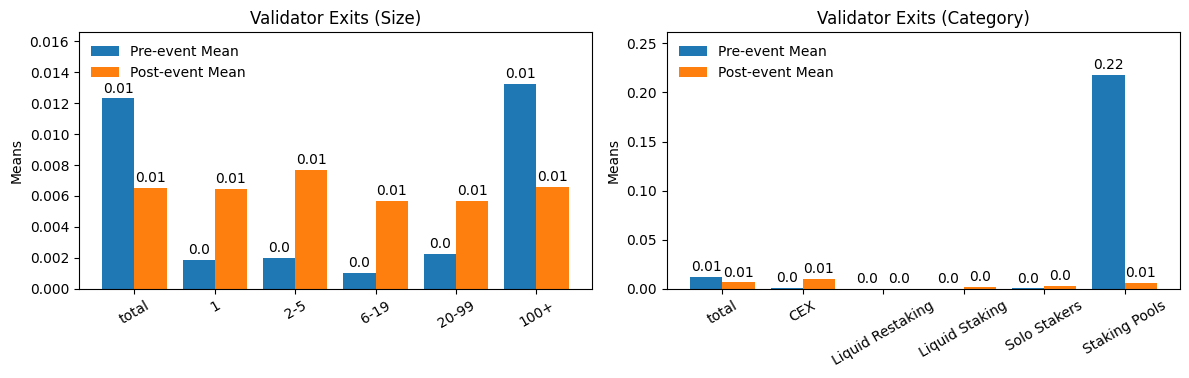

In [348]:
import matplotlib.pyplot as plt

# Extract columns and their respective pre-event and post-event means from the statistics
def extract_means(statistics):
    columns = [result[0] for result in statistics]
    pre_event_means = [result[1] for result in statistics]
    post_event_means = [result[3] for result in statistics]
    return columns, pre_event_means, post_event_means

columns_size, pre_event_means_size, post_event_means_size = extract_means(statistics_size)
columns_cat, pre_event_means_cat, post_event_means_cat = extract_means(statistics_cat)

# Create bar graphs to visualize the pre-event and post-event means
x_size = range(len(columns_size))  # the label locations for size statistics
x_cat = range(len(columns_cat))    # the label locations for category statistics
width = 0.4  # the width of the bars

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))  # Create subplots for side-by-side visualization

# Plot for size statistics
bars1_size = ax1.bar(x_size, pre_event_means_size, width, label='Pre-event Mean')
bars2_size = ax1.bar([i + width for i in x_size], post_event_means_size, width, label='Post-event Mean')

# Calculate y-axis limits
max_height_size = max(pre_event_means_size + post_event_means_size)
ax1.set_ylim(0, max_height_size * 1.25)  # Add 20% to the max height for y-axis limit

ax1.set_ylabel('Means')
ax1.set_title('Validator Exits (Size)')
ax1.set_xticks([i + width / 2 for i in x_size])
ax1.set_xticklabels(columns_size, rotation=30, ha='center')
ax1.legend(frameon=False)

# Attach a text label above each bar in bars1_size and bars2_size, displaying its height.
for bars in [bars1_size, bars2_size]:
    for bar in bars:
        height = bar.get_height()
        ax1.annotate('{}'.format(round(height, 2)),
                     xy=(bar.get_x() + bar.get_width() / 2, height),
                     xytext=(0, 2),  # Increased vertical offset to avoid overlapping with the box
                     textcoords="offset points",
                     ha='center', va='bottom')

# Plot for category statistics
bars1_cat = ax2.bar(x_cat, pre_event_means_cat, width, label='Pre-event Mean')
bars2_cat = ax2.bar([i + width for i in x_cat], post_event_means_cat, width, label='Post-event Mean')

# Calculate y-axis limits
max_height_cat = max(pre_event_means_cat + post_event_means_cat)
ax2.set_ylim(0, max_height_cat * 1.2)  # Add 20% to the max height for y-axis limit

ax2.set_ylabel('Means')
ax2.set_title('Validator Exits (Category)')
ax2.set_xticks([i + width / 2 for i in x_cat])
ax2.set_xticklabels(columns_cat, rotation=30, ha='center')
ax2.legend(frameon=False)

# Attach a text label above each bar in bars1_cat and bars2_cat, displaying its height.
for bars in [bars1_cat, bars2_cat]:
    for bar in bars:
        height = bar.get_height()
        ax2.annotate('{}'.format(round(height, 2)),
                     xy=(bar.get_x() + bar.get_width() / 2, height),
                     xytext=(0, 2),  # Increased vertical offset to avoid overlapping with the box
                     textcoords="offset points",
                     ha='center', va='bottom')

# Add a title


fig.tight_layout(rect=[0, 0, 1, 0.97])

plt.show()


In [349]:
import pandas as pd
from scipy import stats

# Assuming `validator_exits_size_percentage` DataFrame is already loaded
df = deposits_percentage_size

# Set the event slot (this is an example, you should replace it with the actual event slot if known)
event_slot = 8175600.0  # Replace with the actual event slot

# Define the event window and estimation window
event_window = 50400  # slots
pre_event_window = df[df['slot'] <= event_slot]
post_event_window = df[df['slot'] > event_slot]

# Filter the slots for the event window
pre_event_df = pre_event_window[(pre_event_window['slot'] > event_slot - event_window) & (pre_event_window['slot'] <= event_slot)]
post_event_df = post_event_window[(post_event_window['slot'] <= event_slot + event_window) & (post_event_window['slot'] > event_slot)]

# Drop NaN values in the pre-event and post-event dataframes
pre_event_df = pre_event_df.dropna()
post_event_df = post_event_df.dropna()

# Columns to analyze
columns = ['1', '2-5', '6-19', '20-99', '100+']

# Function to calculate statistics and perform t-tests
def calculate_statistics(pre_event_df, post_event_df, columns):
    results = []

    # Calculate and append the 'total' row
    pre_event_total_mean = pre_event_df['total'].mean()
    pre_event_total_std = pre_event_df['total'].std()
    post_event_total_mean = post_event_df['total'].mean()
    post_event_total_std = post_event_df['total'].std()
    total_count = pre_event_df['total'].count() + post_event_df['total'].count()

    results.append(['total', pre_event_total_mean, pre_event_total_std, post_event_total_mean, post_event_total_std, 0, 0, total_count])

    for column in columns:
        pre_event_mean = pre_event_df[column].mean()
        pre_event_std = pre_event_df[column].std()
        post_event_mean = post_event_df[column].mean()
        post_event_std = post_event_df[column].std()

        # Calculate the relative change (elasticity)
        pre_event_change = (pre_event_df[column] / pre_event_df['total']).mean()
        post_event_change = (post_event_df[column] / post_event_df['total']).mean()

        # Drop NaN values for the specific column analysis
        pre_event_col = (pre_event_df[column] / pre_event_df['total']).dropna()
        post_event_col = (post_event_df[column] / post_event_df['total']).dropna()

        if len(pre_event_col) > 0 and len(post_event_col) > 0:
            t_stat, p_value = stats.ttest_ind(pre_event_col, post_event_col, equal_var=False)
        else:
            t_stat, p_value = float('nan'), float('nan')

        pre_event_count = pre_event_df[column].count()
        post_event_count = post_event_df[column].count()

        results.append([column, pre_event_mean, pre_event_std, post_event_mean, post_event_std, t_stat, p_value, pre_event_count + post_event_count])
    return results

# Calculate statistics for each column
statistics_size = calculate_statistics(pre_event_df, post_event_df, columns)

# Print the results
print(f"{'Column':<10} {'Pre-event Mean':<15} {'Pre-event Std':<15} {'Post-event Mean':<15} {'Post-event Std':<15} {'T-stat':<10} {'P-value':<10} {'Count (N)':<10}")
for result in statistics_size:
    print(f"{result[0]:<10} {result[1]:<15.4f} {result[2]:<15.4f} {result[3]:<15.4f} {result[4]:<15.4f} {result[5]:<10.4f} {result[6]:<10.4f} {result[7]:<10}")




Column     Pre-event Mean  Pre-event Std   Post-event Mean Post-event Std  T-stat     P-value    Count (N) 
total      0.2195          0.6904          0.2361          0.6867          0.0000     0.0000     336       
1          0.2331          0.7646          0.1888          0.5538          0.8072     0.4235     336       
2-5        0.1974          0.5978          0.2052          0.6242          0.6400     0.5253     336       
6-19       0.2119          0.7318          0.1980          0.7447          1.6415     0.1121     336       
20-99      0.5159          4.3083          0.1574          0.8221          1.0003     0.3225     336       
100+       0.2056          0.6566          0.2416          0.7181          -2.0405    0.0482     336       


In [360]:
import pandas as pd
from scipy import stats

# Assuming `validator_exits_size_percentage` DataFrame is already loaded
df = deposits_percentage_category

# Set the event slot (this is an example, you should replace it with the actual event slot if known)
event_slot = 8175600.0  # Replace with the actual event slot

# Define the event window and estimation window
event_window = 50400  # slots
pre_event_window = df[df['slot'] <= event_slot]
post_event_window = df[df['slot'] > event_slot]

# Filter the slots for the event window
pre_event_df = pre_event_window[(pre_event_window['slot'] > event_slot - event_window) & (pre_event_window['slot'] <= event_slot)]
post_event_df = post_event_window[(post_event_window['slot'] <= event_slot + event_window) & (post_event_window['slot'] > event_slot)]

# Columns to analyze
columns = df.columns.drop(['slot', 'Unidentified', 'total'])

# Function to calculate statistics and perform t-tests
def calculate_statistics(pre_event_df, post_event_df, columns):
    results = []

    # Calculate and append the 'total' row
    pre_event_total_mean = pre_event_df['total'].mean()
    pre_event_total_std = pre_event_df['total'].std()
    post_event_total_mean = post_event_df['total'].mean()
    post_event_total_std = post_event_df['total'].std()
    total_count = pre_event_df['total'].count() + post_event_df['total'].count()

    results.append(['total', pre_event_total_mean, pre_event_total_std, post_event_total_mean, post_event_total_std, 0, 0, total_count])

    for column in columns:
        pre_event_mean = pre_event_df[column].mean()
        pre_event_std = pre_event_df[column].std()
        post_event_mean = post_event_df[column].mean()
        post_event_std = post_event_df[column].std()

        # Calculate the relative change (elasticity)
        pre_event_change = (pre_event_df[column] / pre_event_df['total']).mean()
        post_event_change = (post_event_df[column] / post_event_df['total']).mean()

        # Drop NaN values for the specific column analysis
        pre_event_col = (pre_event_df[column] / pre_event_df['total']).dropna()
        post_event_col = (post_event_df[column] / post_event_df['total']).dropna()

        if len(pre_event_col) > 0 and len(post_event_col) > 0:
            t_stat, p_value = stats.ttest_ind(pre_event_col, post_event_col, equal_var=False)
        else:
            t_stat, p_value = float('nan'), float('nan')

        pre_event_count = pre_event_df[column].count()
        post_event_count = post_event_df[column].count()

        results.append([column, pre_event_mean, pre_event_std, post_event_mean, post_event_std, t_stat, p_value, pre_event_count + post_event_count])
    return results

# Calculate statistics for each column
statistics_cat = calculate_statistics(pre_event_df, post_event_df, columns)

# Print the results
print(f"{'Column':<15} {'Pre-event Mean':<15} {'Pre-event Std':<15} {'Post-event Mean':<15} {'Post-event Std':<15} {'T-stat':<10} {'P-value':<10} {'Count (N)':<10}")
for result in statistics_cat:
    print(f"{result[0]:<15} {result[1]:<15.4f} {result[2]:<15.4f} {result[3]:<15.4f} {result[4]:<15.4f} {result[5]:<10.4f} {result[6]:<10.4f} {result[7]:<10}")




Column          Pre-event Mean  Pre-event Std   Post-event Mean Post-event Std  T-stat     P-value    Count (N) 
total           0.2195          0.6904          0.2361          0.6867          0.0000     0.0000     336       
CEX             0.1278          0.4419          0.1589          0.5420          -0.7721    0.4440     336       
Liquid Restaking 1.7794          6.6120          3.5688          14.0832         -2.4069    0.0218     336       
Liquid Staking  0.1503          0.8737          0.0938          0.5747          1.8667     0.0685     336       
Solo Stakers    0.0546          0.5662          0.0248          0.1457          0.8115     0.4236     336       
Staking Pools   0.7776          3.8646          1.3224          7.5208          -0.4340    0.6663     336       


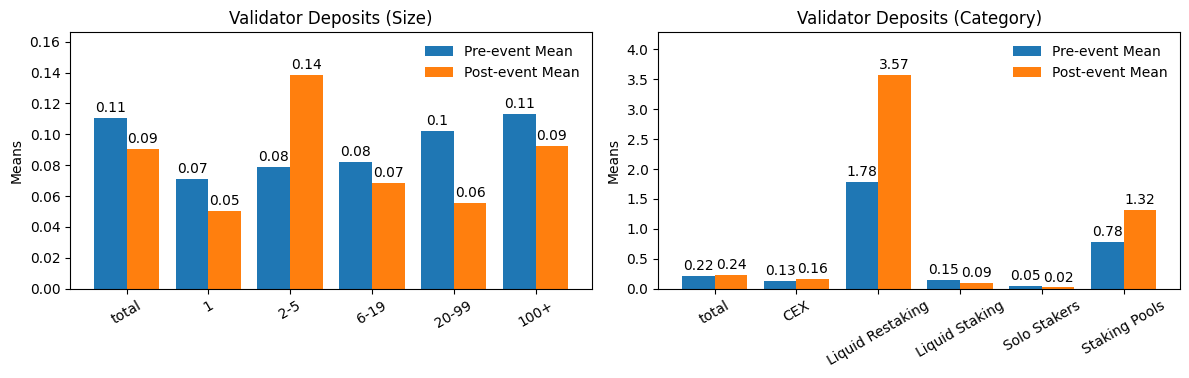

In [361]:
import matplotlib.pyplot as plt

# Extract columns and their respective pre-event and post-event means from the statistics
def extract_means(statistics):
    columns = [result[0] for result in statistics]
    pre_event_means = [result[1] for result in statistics]
    post_event_means = [result[3] for result in statistics]
    return columns, pre_event_means, post_event_means

columns_size, pre_event_means_size, post_event_means_size = extract_means(statistics_size)
columns_cat, pre_event_means_cat, post_event_means_cat = extract_means(statistics_cat)

# Create bar graphs to visualize the pre-event and post-event means
x_size = range(len(columns_size))  # the label locations for size statistics
x_cat = range(len(columns_cat))    # the label locations for category statistics
width = 0.4  # the width of the bars

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))  # Create subplots for side-by-side visualization

# Plot for size statistics
bars1_size = ax1.bar(x_size, pre_event_means_size, width, label='Pre-event Mean')
bars2_size = ax1.bar([i + width for i in x_size], post_event_means_size, width, label='Post-event Mean')

# Calculate y-axis limits
max_height_size = max(pre_event_means_size + post_event_means_size)
ax1.set_ylim(0, max_height_size * 1.2)  # Add 20% to the max height for y-axis limit

ax1.set_ylabel('Means')
ax1.set_title('Validator Deposits (Size)')
ax1.set_xticks([i + width / 2 for i in x_size])
ax1.set_xticklabels(columns_size, rotation=30, ha='center')
ax1.legend(frameon=False)

# Attach a text label above each bar in bars1_size and bars2_size, displaying its height.
for bars in [bars1_size, bars2_size]:
    for bar in bars:
        height = bar.get_height()
        ax1.annotate('{}'.format(round(height, 2)),
                     xy=(bar.get_x() + bar.get_width() / 2, height),
                     xytext=(0, 2),  # Increased vertical offset to avoid overlapping with the box
                     textcoords="offset points",
                     ha='center', va='bottom')

# Plot for category statistics
bars1_cat = ax2.bar(x_cat, pre_event_means_cat, width, label='Pre-event Mean')
bars2_cat = ax2.bar([i + width for i in x_cat], post_event_means_cat, width, label='Post-event Mean')

# Calculate y-axis limits
max_height_cat = max(pre_event_means_cat + post_event_means_cat)
ax2.set_ylim(0, max_height_cat * 1.2)  # Add 20% to the max height for y-axis limit

ax2.set_ylabel('Means')
ax2.set_title('Validator Deposits (Category)')
ax2.set_xticks([i + width / 2 for i in x_cat])
ax2.set_xticklabels(columns_cat, rotation=30, ha='center')
ax2.legend(frameon=False)

# Attach a text label above each bar in bars1_cat and bars2_cat, displaying its height.
for bars in [bars1_cat, bars2_cat]:
    for bar in bars:
        height = bar.get_height()
        ax2.annotate('{}'.format(round(height, 2)),
                     xy=(bar.get_x() + bar.get_width() / 2, height),
                     xytext=(0, 2),  # Increased vertical offset to avoid overlapping with the box
                     textcoords="offset points",
                     ha='center', va='bottom')

# Add a title


fig.tight_layout(rect=[0, 0, 1, 0.97])

plt.show()


# Ether.fi launch

In [362]:
import pandas as pd
from scipy import stats

# Assuming `validator_exits_size_percentage` DataFrame is already loaded
df = validator_exits_size_percentage

# Set the event slot (this is an example, you should replace it with the actual event slot if known)
event_slot = 6552300.0  # Replace with the actual event slot

# Define the event window and estimation window
event_window = 50400  # slots
pre_event_window = df[df['slot'] <= event_slot]
post_event_window = df[df['slot'] > event_slot]

# Filter the slots for the event window
pre_event_df = pre_event_window[(pre_event_window['slot'] > event_slot - event_window) & (pre_event_window['slot'] <= event_slot)]
post_event_df = post_event_window[(post_event_window['slot'] <= event_slot + event_window) & (post_event_window['slot'] > event_slot)]

# Drop NaN values in the pre-event and post-event dataframes
pre_event_df = pre_event_df.dropna()
post_event_df = post_event_df.dropna()

# Columns to analyze
columns = ['1', '2-5', '6-19', '20-99', '100+']

# Function to calculate statistics and perform t-tests
def calculate_statistics(pre_event_df, post_event_df, columns):
    results = []

    # Calculate and append the 'total' row
    pre_event_total_mean = pre_event_df['total'].mean()
    pre_event_total_std = pre_event_df['total'].std()
    post_event_total_mean = post_event_df['total'].mean()
    post_event_total_std = post_event_df['total'].std()
    total_count = pre_event_df['total'].count() + post_event_df['total'].count()

    results.append(['total', pre_event_total_mean, pre_event_total_std, post_event_total_mean, post_event_total_std, 0, 0, total_count])

    for column in columns:
        pre_event_mean = pre_event_df[column].mean()
        pre_event_std = pre_event_df[column].std()
        post_event_mean = post_event_df[column].mean()
        post_event_std = post_event_df[column].std()

        # Calculate the relative change (elasticity)
        pre_event_change = (pre_event_df[column] / pre_event_df['total']).mean()
        post_event_change = (post_event_df[column] / post_event_df['total']).mean()

        # Drop NaN values for the specific column analysis
        pre_event_col = (pre_event_df[column] / pre_event_df['total']).dropna()
        post_event_col = (post_event_df[column] / post_event_df['total']).dropna()

        if len(pre_event_col) > 0 and len(post_event_col) > 0:
            t_stat, p_value = stats.ttest_ind(pre_event_col, post_event_col, equal_var=False)
        else:
            t_stat, p_value = float('nan'), float('nan')

        pre_event_count = pre_event_df[column].count()
        post_event_count = post_event_df[column].count()

        results.append([column, pre_event_mean, pre_event_std, post_event_mean, post_event_std, t_stat, p_value, pre_event_count + post_event_count])
    return results

# Calculate statistics for each column
statistics_size = calculate_statistics(pre_event_df, post_event_df, columns)

# Print the results
print(f"{'Column':<10} {'Pre-event Mean':<15} {'Pre-event Std':<15} {'Post-event Mean':<15} {'Post-event Std':<15} {'T-stat':<10} {'P-value':<10} {'Count (N)':<10}")
for result in statistics_size:
    print(f"{result[0]:<10} {result[1]:<15.4f} {result[2]:<15.4f} {result[3]:<15.4f} {result[4]:<15.4f} {result[5]:<10.4f} {result[6]:<10.4f} {result[7]:<10}")




Column     Pre-event Mean  Pre-event Std   Post-event Mean Post-event Std  T-stat     P-value    Count (N) 
total      0.0021          0.0038          0.0023          0.0039          0.0000     0.0000     336       
1          0.0033          0.0074          0.0038          0.0102          0.3602     0.7190     336       
2-5        0.0030          0.0080          0.0033          0.0122          0.2066     0.8365     336       
6-19       0.0027          0.0143          0.0036          0.0157          1.3726     0.1712     336       
20-99      0.0022          0.0164          0.0017          0.0112          1.1610     0.2469     336       
100+       0.0021          0.0041          0.0022          0.0042          -1.7036    0.0897     336       


In [363]:
import pandas as pd
from scipy import stats

# Assuming `validator_exits_size_percentage` DataFrame is already loaded
df = validator_exits_category_percentage

# Set the event slot (this is an example, you should replace it with the actual event slot if known)
event_slot = 6552300.0  # Replace with the actual event slot

# Define the event window and estimation window
event_window = 50400  # slots
pre_event_window = df[df['slot'] <= event_slot]
post_event_window = df[df['slot'] > event_slot]

# Filter the slots for the event window
pre_event_df = pre_event_window[(pre_event_window['slot'] > event_slot - event_window) & (pre_event_window['slot'] <= event_slot)]
post_event_df = post_event_window[(post_event_window['slot'] <= event_slot + event_window) & (post_event_window['slot'] > event_slot)]

# Columns to analyze
columns = df.columns.drop(['slot', 'Unidentified', 'total'])

# Function to calculate statistics and perform t-tests
def calculate_statistics(pre_event_df, post_event_df, columns):
    results = []

    # Calculate and append the 'total' row
    pre_event_total_mean = pre_event_df['total'].mean()
    pre_event_total_std = pre_event_df['total'].std()
    post_event_total_mean = post_event_df['total'].mean()
    post_event_total_std = post_event_df['total'].std()
    total_count = pre_event_df['total'].count() + post_event_df['total'].count()

    results.append(['total', pre_event_total_mean, pre_event_total_std, post_event_total_mean, post_event_total_std, 0, 0, total_count])

    for column in columns:
        pre_event_mean = pre_event_df[column].mean()
        pre_event_std = pre_event_df[column].std()
        post_event_mean = post_event_df[column].mean()
        post_event_std = post_event_df[column].std()

        # Calculate the relative change (elasticity)
        pre_event_change = (pre_event_df[column] / pre_event_df['total']).mean()
        post_event_change = (post_event_df[column] / post_event_df['total']).mean()

        # Drop NaN values for the specific column analysis
        pre_event_col = (pre_event_df[column] / pre_event_df['total']).dropna()
        post_event_col = (post_event_df[column] / post_event_df['total']).dropna()

        if len(pre_event_col) > 0 and len(post_event_col) > 0:
            t_stat, p_value = stats.ttest_ind(pre_event_col, post_event_col, equal_var=False)
        else:
            t_stat, p_value = float('nan'), float('nan')

        pre_event_count = pre_event_df[column].count()
        post_event_count = post_event_df[column].count()

        results.append([column, pre_event_mean, pre_event_std, post_event_mean, post_event_std, t_stat, p_value, pre_event_count + post_event_count])
    return results

# Calculate statistics for each column
statistics_cat = calculate_statistics(pre_event_df, post_event_df, columns)

# Print the results
print(f"{'Column':<15} {'Pre-event Mean':<15} {'Pre-event Std':<15} {'Post-event Mean':<15} {'Post-event Std':<15} {'T-stat':<10} {'P-value':<10} {'Count (N)':<10}")
for result in statistics_cat:
    print(f"{result[0]:<15} {result[1]:<15.4f} {result[2]:<15.4f} {result[3]:<15.4f} {result[4]:<15.4f} {result[5]:<10.4f} {result[6]:<10.4f} {result[7]:<10}")




Column          Pre-event Mean  Pre-event Std   Post-event Mean Post-event Std  T-stat     P-value    Count (N) 
total           0.0021          0.0038          0.0023          0.0039          0.0000     0.0000     336       
CEX             0.0058          0.0119          0.0052          0.0113          0.9489     0.3436     336       
Liquid Restaking 0.0000          0.0000          0.0000          0.0000          nan        nan        336       
Liquid Staking  0.0002          0.0009          0.0001          0.0004          -0.1316    0.8954     336       
Solo Stakers    0.0006          0.0041          0.0013          0.0104          0.4159     0.6779     336       
Staking Pools   0.0001          0.0007          0.0037          0.0177          -3.9844    0.0001     336       


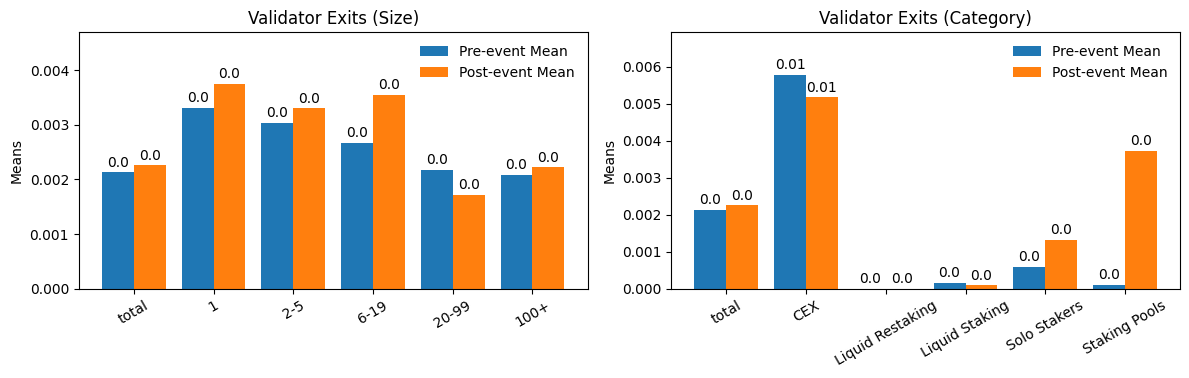

In [364]:
import matplotlib.pyplot as plt

# Extract columns and their respective pre-event and post-event means from the statistics
def extract_means(statistics):
    columns = [result[0] for result in statistics]
    pre_event_means = [result[1] for result in statistics]
    post_event_means = [result[3] for result in statistics]
    return columns, pre_event_means, post_event_means

columns_size, pre_event_means_size, post_event_means_size = extract_means(statistics_size)
columns_cat, pre_event_means_cat, post_event_means_cat = extract_means(statistics_cat)

# Create bar graphs to visualize the pre-event and post-event means
x_size = range(len(columns_size))  # the label locations for size statistics
x_cat = range(len(columns_cat))    # the label locations for category statistics
width = 0.4  # the width of the bars

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))  # Create subplots for side-by-side visualization

# Plot for size statistics
bars1_size = ax1.bar(x_size, pre_event_means_size, width, label='Pre-event Mean')
bars2_size = ax1.bar([i + width for i in x_size], post_event_means_size, width, label='Post-event Mean')

# Calculate y-axis limits
max_height_size = max(pre_event_means_size + post_event_means_size)
ax1.set_ylim(0, max_height_size * 1.25)  # Add 20% to the max height for y-axis limit

ax1.set_ylabel('Means')
ax1.set_title('Validator Exits (Size)')
ax1.set_xticks([i + width / 2 for i in x_size])
ax1.set_xticklabels(columns_size, rotation=30, ha='center')
ax1.legend(frameon=False)

# Attach a text label above each bar in bars1_size and bars2_size, displaying its height.
for bars in [bars1_size, bars2_size]:
    for bar in bars:
        height = bar.get_height()
        ax1.annotate('{}'.format(round(height, 2)),
                     xy=(bar.get_x() + bar.get_width() / 2, height),
                     xytext=(0, 2),  # Increased vertical offset to avoid overlapping with the box
                     textcoords="offset points",
                     ha='center', va='bottom')

# Plot for category statistics
bars1_cat = ax2.bar(x_cat, pre_event_means_cat, width, label='Pre-event Mean')
bars2_cat = ax2.bar([i + width for i in x_cat], post_event_means_cat, width, label='Post-event Mean')

# Calculate y-axis limits
max_height_cat = max(pre_event_means_cat + post_event_means_cat)
ax2.set_ylim(0, max_height_cat * 1.2)  # Add 20% to the max height for y-axis limit

ax2.set_ylabel('Means')
ax2.set_title('Validator Exits (Category)')
ax2.set_xticks([i + width / 2 for i in x_cat])
ax2.set_xticklabels(columns_cat, rotation=30, ha='center')
ax2.legend(frameon=False)

# Attach a text label above each bar in bars1_cat and bars2_cat, displaying its height.
for bars in [bars1_cat, bars2_cat]:
    for bar in bars:
        height = bar.get_height()
        ax2.annotate('{}'.format(round(height, 2)),
                     xy=(bar.get_x() + bar.get_width() / 2, height),
                     xytext=(0, 2),  # Increased vertical offset to avoid overlapping with the box
                     textcoords="offset points",
                     ha='center', va='bottom')

# Add a title


fig.tight_layout(rect=[0, 0, 1, 0.97])

plt.show()


In [365]:
import pandas as pd
from scipy import stats

# Assuming `validator_exits_size_percentage` DataFrame is already loaded
df = deposits_percentage_size

# Set the event slot (this is an example, you should replace it with the actual event slot if known)
event_slot = 6552300.0  # Replace with the actual event slot

# Define the event window and estimation window
event_window = 50400  # slots
pre_event_window = df[df['slot'] <= event_slot]
post_event_window = df[df['slot'] > event_slot]

# Filter the slots for the event window
pre_event_df = pre_event_window[(pre_event_window['slot'] > event_slot - event_window) & (pre_event_window['slot'] <= event_slot)]
post_event_df = post_event_window[(post_event_window['slot'] <= event_slot + event_window) & (post_event_window['slot'] > event_slot)]

# Drop NaN values in the pre-event and post-event dataframes
pre_event_df = pre_event_df.dropna()
post_event_df = post_event_df.dropna()

# Columns to analyze
columns = ['1', '2-5', '6-19', '20-99', '100+']

# Function to calculate statistics and perform t-tests
def calculate_statistics(pre_event_df, post_event_df, columns):
    results = []

    # Calculate and append the 'total' row
    pre_event_total_mean = pre_event_df['total'].mean()
    pre_event_total_std = pre_event_df['total'].std()
    post_event_total_mean = post_event_df['total'].mean()
    post_event_total_std = post_event_df['total'].std()
    total_count = pre_event_df['total'].count() + post_event_df['total'].count()

    results.append(['total', pre_event_total_mean, pre_event_total_std, post_event_total_mean, post_event_total_std, 0, 0, total_count])

    for column in columns:
        pre_event_mean = pre_event_df[column].mean()
        pre_event_std = pre_event_df[column].std()
        post_event_mean = post_event_df[column].mean()
        post_event_std = post_event_df[column].std()

        # Calculate the relative change (elasticity)
        pre_event_change = (pre_event_df[column] / pre_event_df['total']).mean()
        post_event_change = (post_event_df[column] / post_event_df['total']).mean()

        # Drop NaN values for the specific column analysis
        pre_event_col = (pre_event_df[column] / pre_event_df['total']).dropna()
        post_event_col = (post_event_df[column] / post_event_df['total']).dropna()

        if len(pre_event_col) > 0 and len(post_event_col) > 0:
            t_stat, p_value = stats.ttest_ind(pre_event_col, post_event_col, equal_var=False)
        else:
            t_stat, p_value = float('nan'), float('nan')

        pre_event_count = pre_event_df[column].count()
        post_event_count = post_event_df[column].count()

        results.append([column, pre_event_mean, pre_event_std, post_event_mean, post_event_std, t_stat, p_value, pre_event_count + post_event_count])
    return results

# Calculate statistics for each column
statistics_size = calculate_statistics(pre_event_df, post_event_df, columns)

# Print the results
print(f"{'Column':<10} {'Pre-event Mean':<15} {'Pre-event Std':<15} {'Post-event Mean':<15} {'Post-event Std':<15} {'T-stat':<10} {'P-value':<10} {'Count (N)':<10}")
for result in statistics_size:
    print(f"{result[0]:<10} {result[1]:<15.4f} {result[2]:<15.4f} {result[3]:<15.4f} {result[4]:<15.4f} {result[5]:<10.4f} {result[6]:<10.4f} {result[7]:<10}")




Column     Pre-event Mean  Pre-event Std   Post-event Mean Post-event Std  T-stat     P-value    Count (N) 
total      0.7217          2.1178          0.9984          3.1864          0.0000     0.0000     336       
1          0.5058          2.3458          0.2692          0.9025          0.6531     0.5170     336       
2-5        0.3187          0.9194          0.2539          0.7220          -0.6755    0.5024     336       
6-19       0.6428          2.4520          0.3513          1.1161          1.0637     0.2920     336       
20-99      0.2963          1.0362          0.4514          2.3151          -1.0977    0.2778     336       
100+       0.7556          2.2593          1.0636          3.4770          0.4947     0.6228     336       


In [366]:
import pandas as pd
from scipy import stats

# Assuming `validator_exits_size_percentage` DataFrame is already loaded
df = deposits_percentage_category

# Set the event slot (this is an example, you should replace it with the actual event slot if known)
event_slot = 6552300.0  # Replace with the actual event slot

# Define the event window and estimation window
event_window = 50400  # slots
pre_event_window = df[df['slot'] <= event_slot]
post_event_window = df[df['slot'] > event_slot]

# Filter the slots for the event window
pre_event_df = pre_event_window[(pre_event_window['slot'] > event_slot - event_window) & (pre_event_window['slot'] <= event_slot)]
post_event_df = post_event_window[(post_event_window['slot'] <= event_slot + event_window) & (post_event_window['slot'] > event_slot)]

# Columns to analyze
columns = df.columns.drop(['slot', 'Unidentified', 'total'])

# Function to calculate statistics and perform t-tests
def calculate_statistics(pre_event_df, post_event_df, columns):
    results = []

    # Calculate and append the 'total' row
    pre_event_total_mean = pre_event_df['total'].mean()
    pre_event_total_std = pre_event_df['total'].std()
    post_event_total_mean = post_event_df['total'].mean()
    post_event_total_std = post_event_df['total'].std()
    total_count = pre_event_df['total'].count() + post_event_df['total'].count()

    results.append(['total', pre_event_total_mean, pre_event_total_std, post_event_total_mean, post_event_total_std, 0, 0, total_count])

    for column in columns:
        pre_event_mean = pre_event_df[column].mean()
        pre_event_std = pre_event_df[column].std()
        post_event_mean = post_event_df[column].mean()
        post_event_std = post_event_df[column].std()

        # Calculate the relative change (elasticity)
        pre_event_change = (pre_event_df[column] / pre_event_df['total']).mean()
        post_event_change = (post_event_df[column] / post_event_df['total']).mean()

        # Drop NaN values for the specific column analysis
        pre_event_col = (pre_event_df[column] / pre_event_df['total']).dropna()
        post_event_col = (post_event_df[column] / post_event_df['total']).dropna()

        if len(pre_event_col) > 0 and len(post_event_col) > 0:
            t_stat, p_value = stats.ttest_ind(pre_event_col, post_event_col, equal_var=False)
        else:
            t_stat, p_value = float('nan'), float('nan')

        pre_event_count = pre_event_df[column].count()
        post_event_count = post_event_df[column].count()

        results.append([column, pre_event_mean, pre_event_std, post_event_mean, post_event_std, t_stat, p_value, pre_event_count + post_event_count])
    return results

# Calculate statistics for each column
statistics_cat = calculate_statistics(pre_event_df, post_event_df, columns)

# Print the results
print(f"{'Column':<15} {'Pre-event Mean':<15} {'Pre-event Std':<15} {'Post-event Mean':<15} {'Post-event Std':<15} {'T-stat':<10} {'P-value':<10} {'Count (N)':<10}")
for result in statistics_cat:
    print(f"{result[0]:<15} {result[1]:<15.4f} {result[2]:<15.4f} {result[3]:<15.4f} {result[4]:<15.4f} {result[5]:<10.4f} {result[6]:<10.4f} {result[7]:<10}")




Column          Pre-event Mean  Pre-event Std   Post-event Mean Post-event Std  T-stat     P-value    Count (N) 
total           0.7217          2.1178          0.9984          3.1864          0.0000     0.0000     336       
CEX             0.6505          2.8398          0.6237          1.9652          -0.4173    0.6780     336       
Liquid Restaking 12.1679         91.4504         3.5280          10.9592         1.2954     0.2057     336       
Liquid Staking  1.0476          3.7664          0.6959          2.0556          2.7009     0.0091     336       
Solo Stakers    0.0552          0.3561          0.0448          0.2721          0.0424     0.9664     336       
Staking Pools   0.3146          1.0993          8.7114          48.9302         -3.4053    0.0017     336       


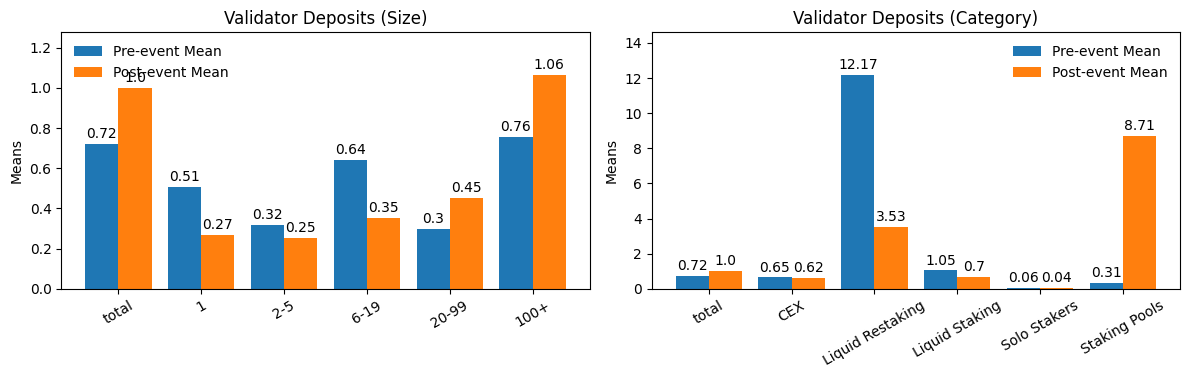

In [367]:
import matplotlib.pyplot as plt

# Extract columns and their respective pre-event and post-event means from the statistics
def extract_means(statistics):
    columns = [result[0] for result in statistics]
    pre_event_means = [result[1] for result in statistics]
    post_event_means = [result[3] for result in statistics]
    return columns, pre_event_means, post_event_means

columns_size, pre_event_means_size, post_event_means_size = extract_means(statistics_size)
columns_cat, pre_event_means_cat, post_event_means_cat = extract_means(statistics_cat)

# Create bar graphs to visualize the pre-event and post-event means
x_size = range(len(columns_size))  # the label locations for size statistics
x_cat = range(len(columns_cat))    # the label locations for category statistics
width = 0.4  # the width of the bars

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))  # Create subplots for side-by-side visualization

# Plot for size statistics
bars1_size = ax1.bar(x_size, pre_event_means_size, width, label='Pre-event Mean')
bars2_size = ax1.bar([i + width for i in x_size], post_event_means_size, width, label='Post-event Mean')

# Calculate y-axis limits
max_height_size = max(pre_event_means_size + post_event_means_size)
ax1.set_ylim(0, max_height_size * 1.2)  # Add 20% to the max height for y-axis limit

ax1.set_ylabel('Means')
ax1.set_title('Validator Deposits (Size)')
ax1.set_xticks([i + width / 2 for i in x_size])
ax1.set_xticklabels(columns_size, rotation=30, ha='center')
ax1.legend(frameon=False)

# Attach a text label above each bar in bars1_size and bars2_size, displaying its height.
for bars in [bars1_size, bars2_size]:
    for bar in bars:
        height = bar.get_height()
        ax1.annotate('{}'.format(round(height, 2)),
                     xy=(bar.get_x() + bar.get_width() / 2, height),
                     xytext=(0, 2),  # Increased vertical offset to avoid overlapping with the box
                     textcoords="offset points",
                     ha='center', va='bottom')

# Plot for category statistics
bars1_cat = ax2.bar(x_cat, pre_event_means_cat, width, label='Pre-event Mean')
bars2_cat = ax2.bar([i + width for i in x_cat], post_event_means_cat, width, label='Post-event Mean')

# Calculate y-axis limits
max_height_cat = max(pre_event_means_cat + post_event_means_cat)
ax2.set_ylim(0, max_height_cat * 1.2)  # Add 20% to the max height for y-axis limit

ax2.set_ylabel('Means')
ax2.set_title('Validator Deposits (Category)')
ax2.set_xticks([i + width / 2 for i in x_cat])
ax2.set_xticklabels(columns_cat, rotation=30, ha='center')
ax2.legend(frameon=False)

# Attach a text label above each bar in bars1_cat and bars2_cat, displaying its height.
for bars in [bars1_cat, bars2_cat]:
    for bar in bars:
        height = bar.get_height()
        ax2.annotate('{}'.format(round(height, 2)),
                     xy=(bar.get_x() + bar.get_width() / 2, height),
                     xytext=(0, 2),  # Increased vertical offset to avoid overlapping with the box
                     textcoords="offset points",
                     ha='center', va='bottom')

# Add a title


fig.tight_layout(rect=[0, 0, 1, 0.97])

plt.show()


# Visualization

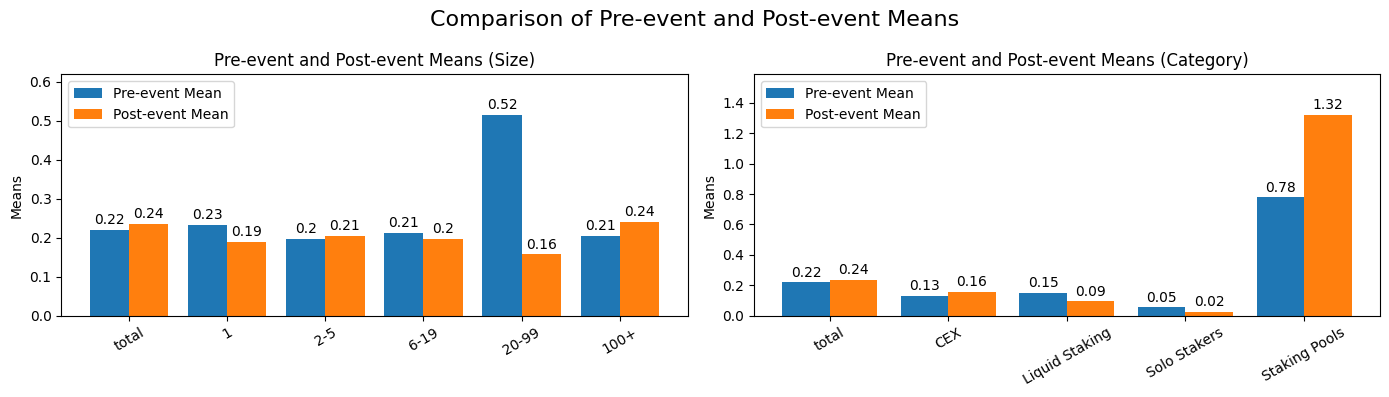

In [352]:
import matplotlib.pyplot as plt

# Extract columns and their respective pre-event and post-event means from the statistics
def extract_means(statistics):
    columns = [result[0] for result in statistics]
    pre_event_means = [result[1] for result in statistics]
    post_event_means = [result[3] for result in statistics]
    return columns, pre_event_means, post_event_means

columns_size, pre_event_means_size, post_event_means_size = extract_means(statistics_size)
columns_cat, pre_event_means_cat, post_event_means_cat = extract_means(statistics_cat)

# Create bar graphs to visualize the pre-event and post-event means
x_size = range(len(columns_size))  # the label locations for size statistics
x_cat = range(len(columns_cat))    # the label locations for category statistics
width = 0.4  # the width of the bars

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))  # Create subplots for side-by-side visualization

# Plot for size statistics
bars1_size = ax1.bar(x_size, pre_event_means_size, width, label='Pre-event Mean')
bars2_size = ax1.bar([i + width for i in x_size], post_event_means_size, width, label='Post-event Mean')

# Calculate y-axis limits
max_height_size = max(pre_event_means_size + post_event_means_size)
ax1.set_ylim(0, max_height_size * 1.2)  # Add 20% to the max height for y-axis limit

ax1.set_ylabel('Means')
ax1.set_title('Pre-event and Post-event Means (Size)')
ax1.set_xticks([i + width / 2 for i in x_size])
ax1.set_xticklabels(columns_size, rotation=30, ha='center')
ax1.legend()

# Attach a text label above each bar in bars1_size and bars2_size, displaying its height.
for bars in [bars1_size, bars2_size]:
    for bar in bars:
        height = bar.get_height()
        ax1.annotate('{}'.format(round(height, 2)),
                     xy=(bar.get_x() + bar.get_width() / 2, height),
                     xytext=(0, 2),  # Increased vertical offset to avoid overlapping with the box
                     textcoords="offset points",
                     ha='center', va='bottom')

# Plot for category statistics
bars1_cat = ax2.bar(x_cat, pre_event_means_cat, width, label='Pre-event Mean')
bars2_cat = ax2.bar([i + width for i in x_cat], post_event_means_cat, width, label='Post-event Mean')

# Calculate y-axis limits
max_height_cat = max(pre_event_means_cat + post_event_means_cat)
ax2.set_ylim(0, max_height_cat * 1.2)  # Add 20% to the max height for y-axis limit

ax2.set_ylabel('Means')
ax2.set_title('Pre-event and Post-event Means (Category)')
ax2.set_xticks([i + width / 2 for i in x_cat])
ax2.set_xticklabels(columns_cat, rotation=30, ha='center')
ax2.legend()

# Attach a text label above each bar in bars1_cat and bars2_cat, displaying its height.
for bars in [bars1_cat, bars2_cat]:
    for bar in bars:
        height = bar.get_height()
        ax2.annotate('{}'.format(round(height, 2)),
                     xy=(bar.get_x() + bar.get_width() / 2, height),
                     xytext=(0, 2),  # Increased vertical offset to avoid overlapping with the box
                     textcoords="offset points",
                     ha='center', va='bottom')

# Add a title
fig.suptitle('Comparison of Pre-event and Post-event Means', fontsize=16)

fig.tight_layout()  # Adjust layout to make room for the title

plt.show()
